# 100-window RPKM profiles with 95% CI

For each 200 bp window, this notebook plots the median RPKM and a non-parametric 95% confidence interval for the median. No mean is calculated. Real and simulated data are plotted separately.

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE = Path('/cta/users/guneyn23')
RPKM_DIR = BASE / 'peak_center_20kb_100w/rpkm'
OUT = RPKM_DIR / 'median_ci95_plots'
OUT.mkdir(parents=True, exist_ok=True)

REGIONS = ['ATAC', 'H3K9me3', 'H3K27me3']
DAMAGES = ['CPD', '64']
KINDS = ['real', 'sim']
TIMES = ['1m', '15m', '30m', '1h', '4h', '8h']
COLORS = {
    '1m': '#01befe',
    '15m': '#ffdd00',
    '30m': '#ff7d00',
    '1h': '#ff006d',
    '4h': '#adff02',
    '8h': '#8f00ff',
}

def rpkm_path(region, damage, time, kind):
    folder = 'real' if kind == 'real' else 'simulated'
    return RPKM_DIR / folder / f'{time}_{damage}_{kind}_{region}_100windows_rpkm.bed'

## Calculate median RPKM and its non-parametric 95% CI

In [3]:
def median_ci95(values):
    values = np.sort(np.asarray(values, dtype=float))
    n = len(values)
    median = np.median(values)

    margin = 1.96 * np.sqrt(n) / 2
    lower_index = max(0, int(np.floor(n / 2 - margin)))
    upper_index = min(n - 1, int(np.ceil(n / 2 + margin)))

    return pd.Series({
        'median_rpkm': median,
        'ci95_lower': values[lower_index],
        'ci95_upper': values[upper_index],
        'n_regions': n,
        'zero_fraction': np.mean(values == 0),
    })

def summarize_rpkm(path):
    data = pd.read_csv(
        path,
        sep='\t',
        header=None,
        usecols=[3, 5],
        names=['peak_window', 'rpkm'],
    )
    data['window'] = data['peak_window'].str.rsplit('_', n=1).str[-1].astype(int)
    return data.groupby('window', sort=True)['rpkm'].apply(median_ci95).unstack()

summaries = []

for region in REGIONS:
    for damage in DAMAGES:
        for kind in KINDS:
            for time in TIMES:
                path = rpkm_path(region, damage, time, kind)
                print('Reading:', path.name)
                table = summarize_rpkm(path).reset_index()
                table.insert(0, 'time', time)
                table.insert(0, 'kind', kind)
                table.insert(0, 'damage', damage)
                table.insert(0, 'region', region)
                table['distance_kb'] = -10 + (table['window'] - 0.5) * 0.2
                summaries.append(table)

summary = pd.concat(summaries, ignore_index=True)
summary.to_csv(OUT / '100windows_rpkm_median_ci95_summary.tsv', sep='\t', index=False)
summary.head()

Reading: 1m_CPD_real_ATAC_100windows_rpkm.bed
Reading: 15m_CPD_real_ATAC_100windows_rpkm.bed
Reading: 30m_CPD_real_ATAC_100windows_rpkm.bed
Reading: 1h_CPD_real_ATAC_100windows_rpkm.bed
Reading: 4h_CPD_real_ATAC_100windows_rpkm.bed
Reading: 8h_CPD_real_ATAC_100windows_rpkm.bed
Reading: 1m_CPD_sim_ATAC_100windows_rpkm.bed
Reading: 15m_CPD_sim_ATAC_100windows_rpkm.bed
Reading: 30m_CPD_sim_ATAC_100windows_rpkm.bed
Reading: 1h_CPD_sim_ATAC_100windows_rpkm.bed
Reading: 4h_CPD_sim_ATAC_100windows_rpkm.bed
Reading: 8h_CPD_sim_ATAC_100windows_rpkm.bed
Reading: 1m_64_real_ATAC_100windows_rpkm.bed
Reading: 15m_64_real_ATAC_100windows_rpkm.bed
Reading: 30m_64_real_ATAC_100windows_rpkm.bed
Reading: 1h_64_real_ATAC_100windows_rpkm.bed
Reading: 4h_64_real_ATAC_100windows_rpkm.bed
Reading: 8h_64_real_ATAC_100windows_rpkm.bed
Reading: 1m_64_sim_ATAC_100windows_rpkm.bed
Reading: 15m_64_sim_ATAC_100windows_rpkm.bed
Reading: 30m_64_sim_ATAC_100windows_rpkm.bed
Reading: 1h_64_sim_ATAC_100windows_rpkm.bed


,region,damage,kind,time,window,median_rpkm,ci95_lower,ci95_upper,n_regions,zero_fraction,distance_kb
0,ATAC,CPD,real,1m,1,0.31,0.31,0.31,48911.0,0.214328,-9.9
1,ATAC,CPD,real,1m,2,0.31,0.31,0.31,48911.0,0.212754,-9.7
2,ATAC,CPD,real,1m,3,0.31,0.31,0.31,48911.0,0.210300,-9.5
3,ATAC,CPD,real,1m,4,0.31,0.31,0.31,48911.0,0.211098,-9.3
4,ATAC,CPD,real,1m,5,0.31,0.31,0.31,48911.0,0.212059,-9.1


## Plot real and simulated profiles separately

The line is the window median; the shaded ribbon is its 95% CI.

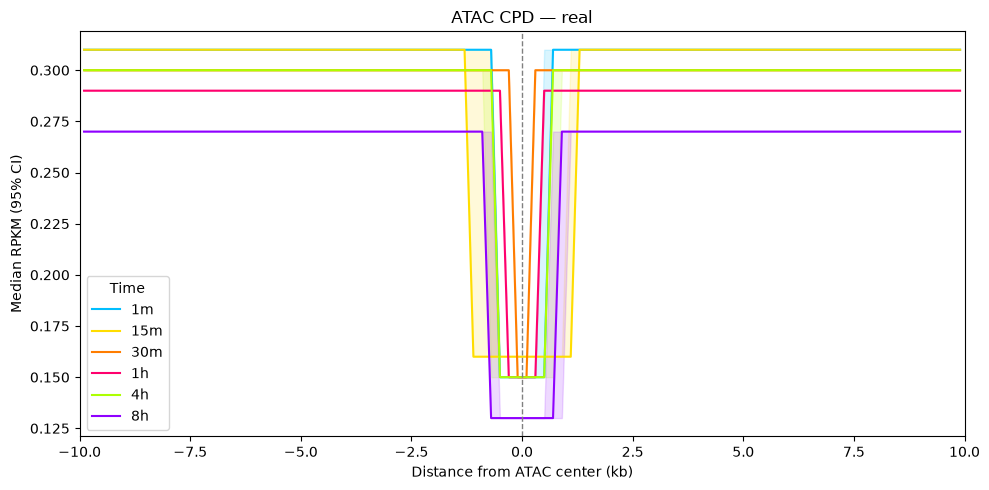

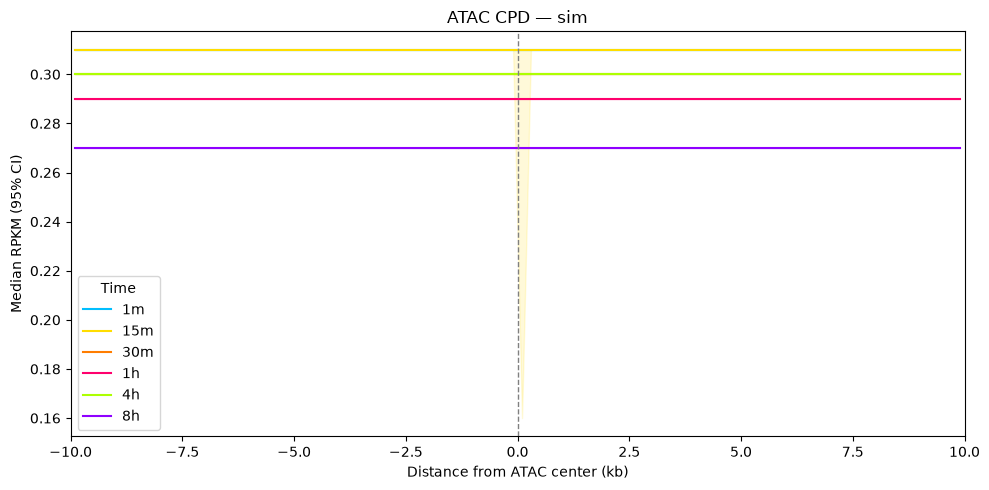

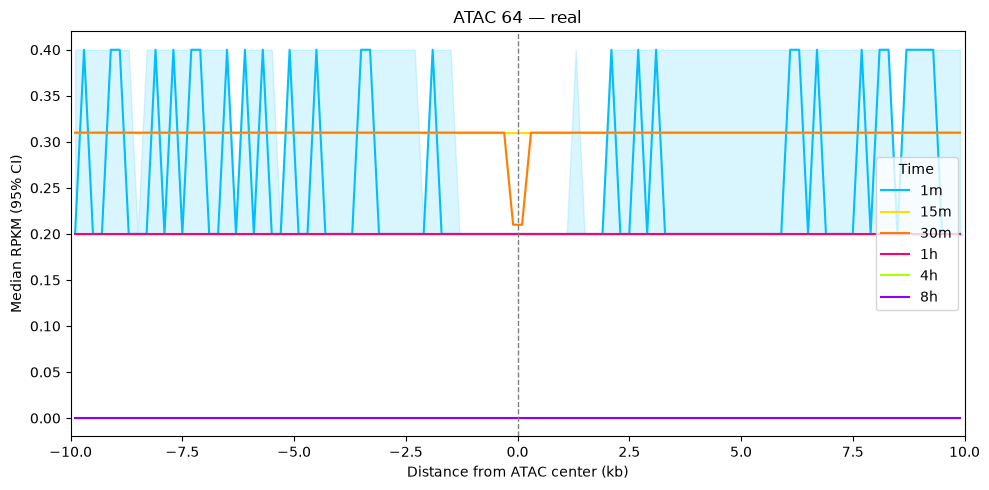

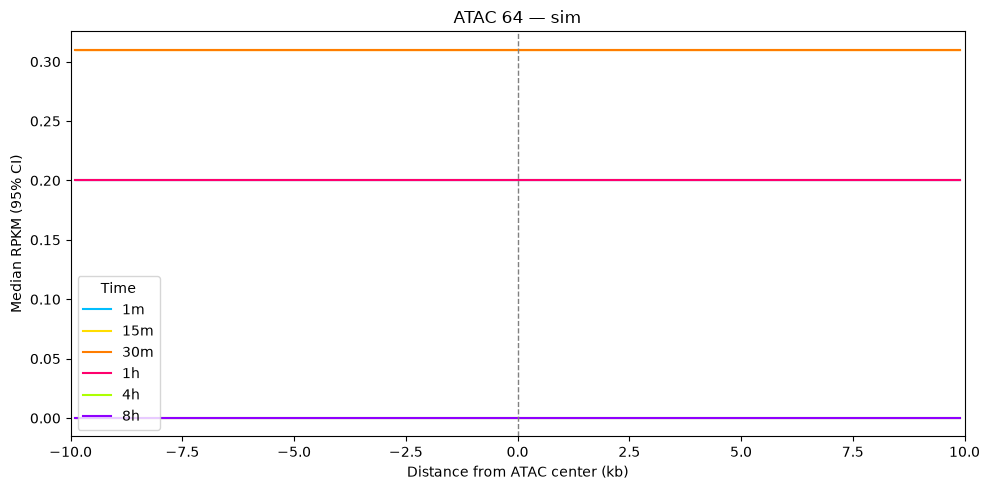

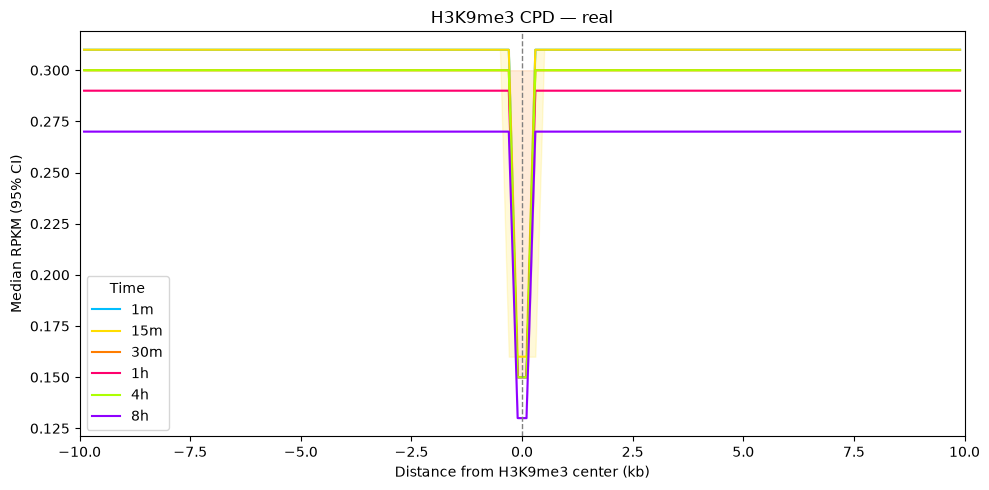

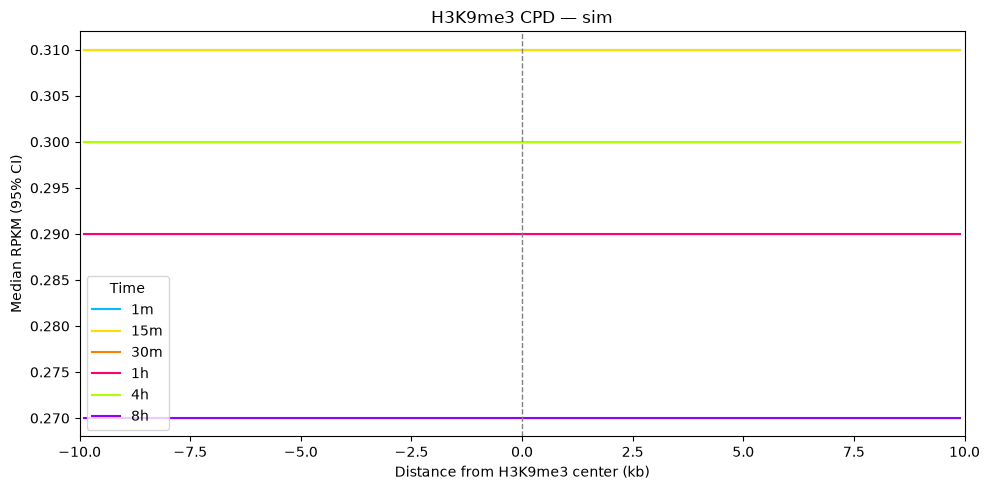

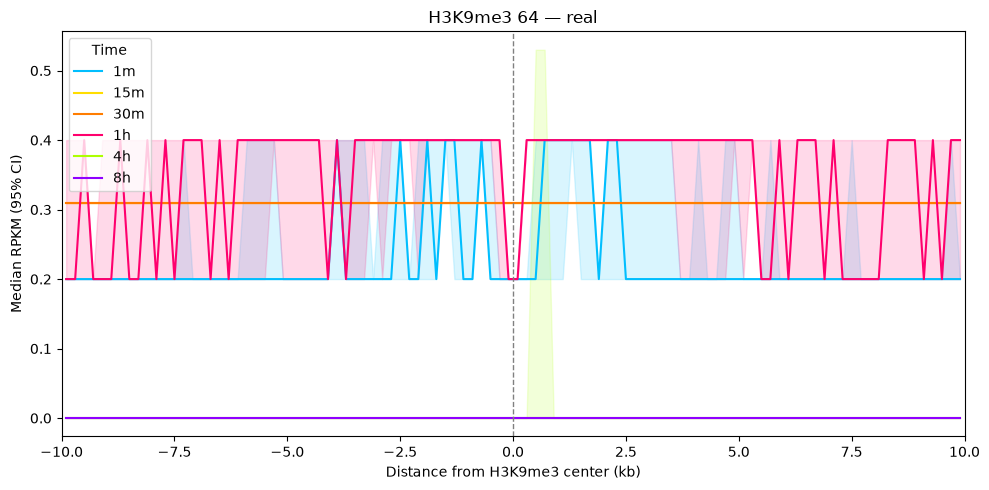

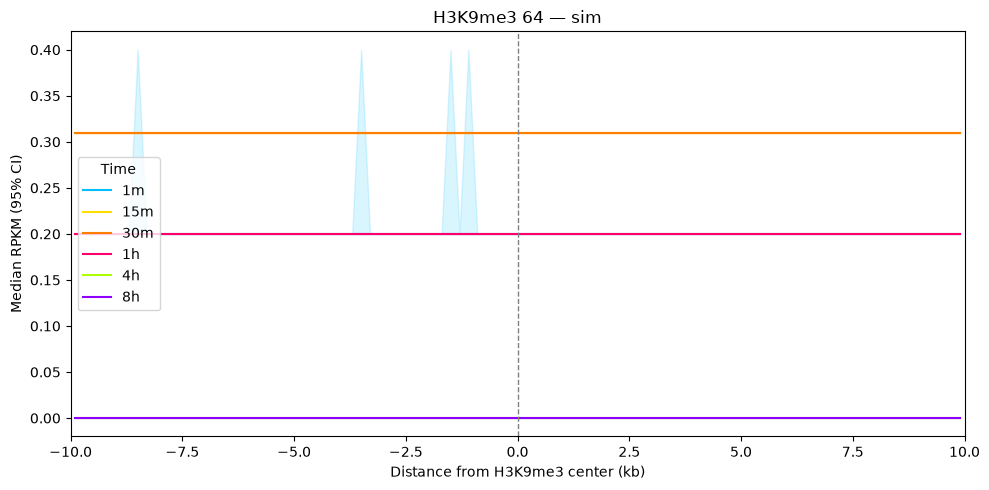

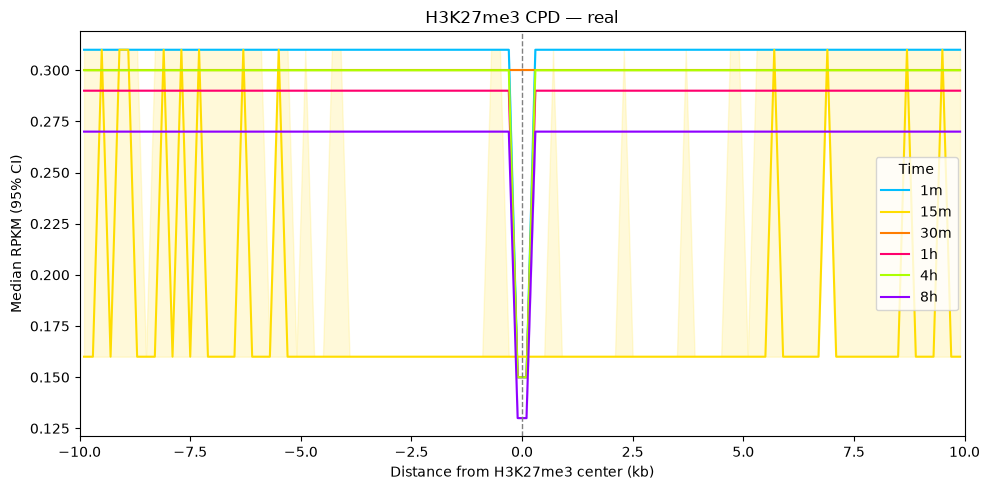

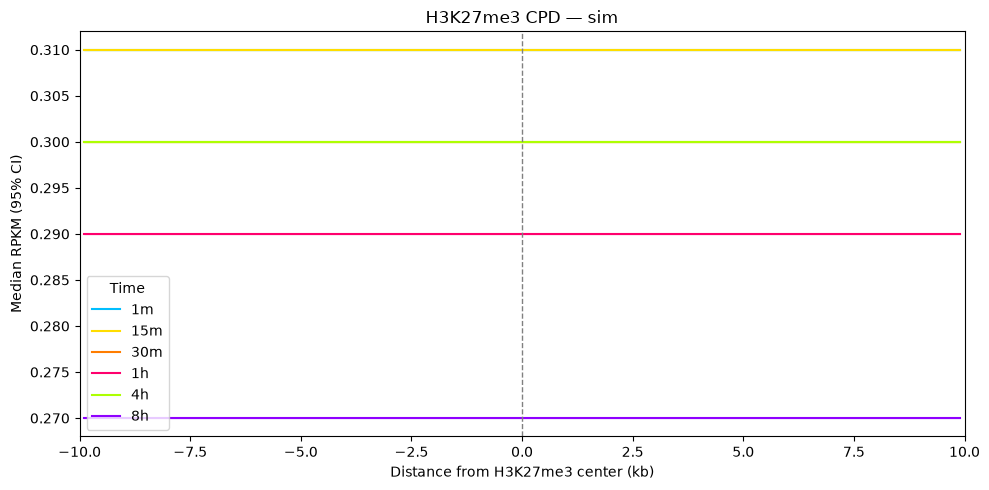

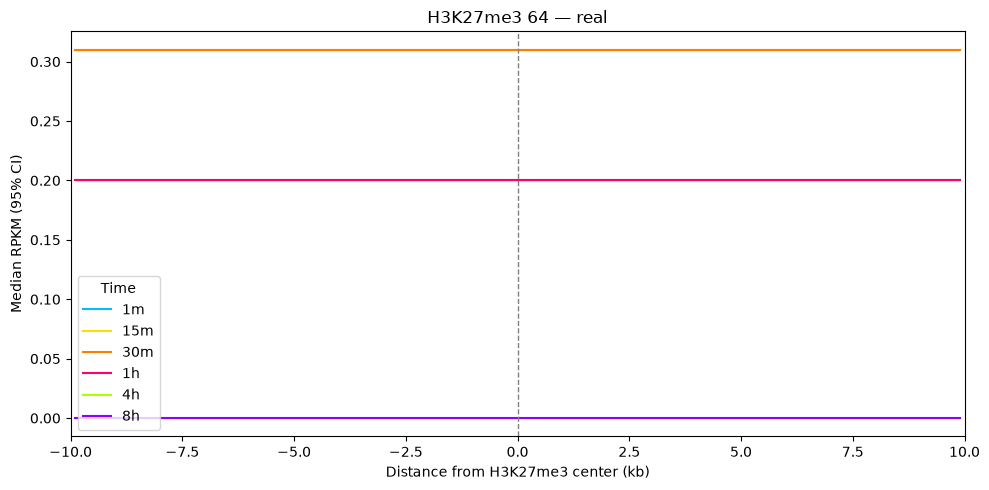

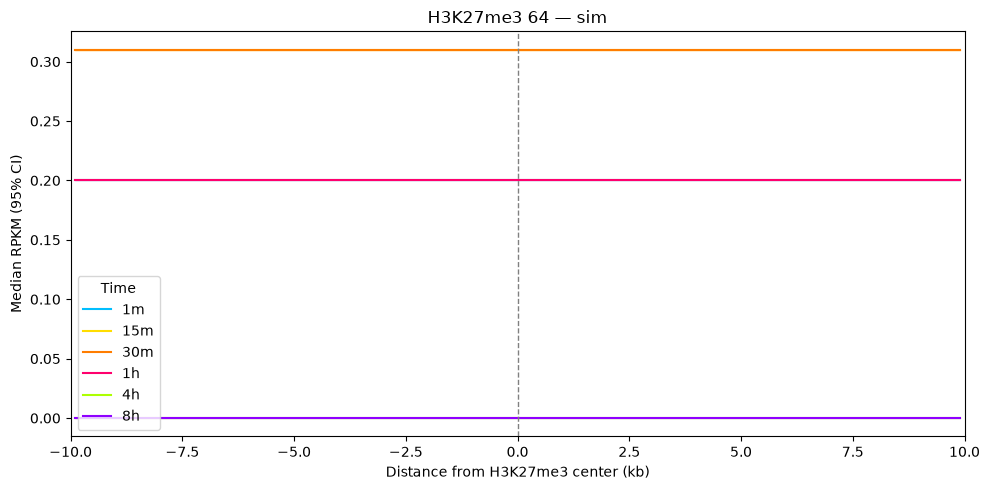

In [4]:
for region in REGIONS:
    for damage in DAMAGES:
        for kind in KINDS:
            selected = summary[
                (summary['region'] == region)
                & (summary['damage'] == damage)
                & (summary['kind'] == kind)
            ]

            fig, ax = plt.subplots(figsize=(10, 5))

            for time in TIMES:
                values = selected[selected['time'] == time].sort_values('window')
                x = values['distance_kb'].to_numpy(dtype=float)
                median = values['median_rpkm'].to_numpy(dtype=float)
                lower = values['ci95_lower'].to_numpy(dtype=float)
                upper = values['ci95_upper'].to_numpy(dtype=float)

                ax.plot(x, median, color=COLORS[time], label=time)
                ax.fill_between(x, lower, upper, color=COLORS[time], alpha=0.15)

            ax.axvline(0, color='gray', linestyle='--', linewidth=1)
            ax.set_xlim(-10, 10)
            ax.set_xlabel(f'Distance from {region} center (kb)')
            ax.set_ylabel('Median RPKM (95% CI)')
            ax.set_title(f'{region} {damage} — {kind}')
            ax.legend(title='Time')
            fig.tight_layout()
            fig.savefig(OUT / f'{region}_{damage}_{kind}_median_rpkm_ci95.png', dpi=300, bbox_inches='tight')
            plt.show()
            plt.close(fig)